# Extreme Value Theory (EVT) Analysis for Load Residuals

This notebook performs EVT analysis on electricity load residuals from 4 US regions:
- Boston
- New York
- Chicago
- Minneapolis

We calculate the Extreme Value Index (EVI) using 8 different estimation methods for both left and right tails.

In [1]:
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.stats import genextreme, genpareto, pareto

from wxderivs import SET_TARGET_US_CITIES, DIR_WORK

# Import unibm module
sys.path.append(str(DIR_WORK / "unibm"))
import unibm
import unibm.benchmark

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")
print(f"✓ Target cities: {SET_TARGET_US_CITIES}")

0 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Essen.csv
1 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Boston.csv
2 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Philadelphia.csv
3 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/NewYork.csv
4 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Burbank.csv
5 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/London.csv
6 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Dallas.csv
7 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Paris.csv
8 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/temperature/Portland.csv
9 /workspaces/Financial-Engineering-Project/notebooks/wxderivs/../../data/raw/tempe

## Load Pre-processed Data

Load the residuals from the seasonal ARMA-GARCH models fitted in `Load_Analytics.ipynb`.

In [2]:
# Load the pickled data from Load_Analytics
with open('../data/processed/all_analysis_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract residuals DataFrame
df_res = data['df_res']

print("✓ Data loaded successfully")
print(f"\nResiduals shape: {df_res.shape}")
print(f"Date range: {df_res.index.min()} to {df_res.index.max()}")
print(f"\nColumns (regions): {df_res.columns.tolist()}")
print(f"\nResiduals summary:")
display(df_res.describe())

✓ Data loaded successfully

Residuals shape: (3286, 4)
Date range: 2014-01-01 00:00:00 to 2022-12-30 00:00:00

Columns (regions): ['Chicago', 'Boston', 'NewYork', 'Minneapolis']

Residuals summary:


,Chicago,Boston,NewYork,Minneapolis
count,3286.000000,3286.000000,3286.000000,3286.000000
mean,-125.926048,1.205759,4.694625,-19.866468
std,2420.240716,192.330296,563.421621,895.646736
min,-10487.065324,-1140.356431,-3251.184255,-2987.937887
25%,-1638.419290,-95.984729,-266.886320,-592.417928
50%,-314.295174,-5.396433,-9.989094,-39.754887
75%,1374.103821,80.928083,240.021343,526.013617
max,37390.096126,2900.982144,8157.543767,16897.966233


## Calculate Extreme Value Index (EVI)

We estimate EVI using 8 different methods:
1. **Hill** - Classic Hill estimator
2. **Schultze-Steinebach** - Bias-reduced estimator
3. **Smith** - Maximum likelihood approach
4. **Meerschaert-Scheffler** - Alternative estimator
5. **GEV (Generalized Extreme Value)** - MLE from scipy
6. **GP (Generalized Pareto)** - MLE from scipy
7. **Pareto** - Classical Pareto MLE
8. **MPMR-WLS** - Weighted least squares on mean excess plot

### Right Tail (Positive Residuals)
High positive residuals indicate days when load exceeded the seasonal model prediction.

In [3]:
# Calculate EVI for RIGHT TAIL (positive residuals)
dct_evi_load_res_right = {}

for station in SET_TARGET_US_CITIES:
    tmp_vec = df_res[station].values
    # Right tail: positive values only
    tmp_vec = tmp_vec[tmp_vec > 0]
    
    print(f"Processing {station} (right tail): {len(tmp_vec)} positive residuals")
    
    dct_evi_load_res_right[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(tmp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(tmp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(tmp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(tmp_vec)
        ),
        "genextreme": genextreme.fit(tmp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(tmp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(tmp_vec, floc=0)[0].item(),
        "mpmr_wls": unibm.est_extreme_value_index(tmp_vec, is_frechet=False)["slope_emr"],
    }

print("\n✓ Right tail EVI calculation complete")

Processing Chicago (right tail): 1475 positive residuals
Processing NewYork (right tail): 1616 positive residuals
Processing Minneapolis (right tail): 1579 positive residuals
Processing Boston (right tail): 1577 positive residuals

✓ Right tail EVI calculation complete


### Left Tail (Negative Residuals)
High negative residuals (converted to positive for analysis) indicate days when load was much lower than predicted.

In [4]:
# Calculate EVI for LEFT TAIL (negative residuals, converted to positive)
dct_evi_load_res_left = {}

for station in SET_TARGET_US_CITIES:
    temp_vec = df_res[station].values
    # Left tail: flip negative values to positive
    temp_vec = -temp_vec[temp_vec < 0]
    
    print(f"Processing {station} (left tail): {len(temp_vec)} negative residuals")
    
    dct_evi_load_res_left[station] = {
        "hill": unibm.benchmark.est_extreme_value_index_hill(torch.tensor(temp_vec)),
        "schultze_steinebach": unibm.benchmark.est_extreme_value_index_schultze_steinebach(
            torch.tensor(temp_vec)
        ),
        "smith": unibm.benchmark.est_extreme_value_index_smith(torch.tensor(temp_vec)),
        "meerschaert_scheffler": unibm.benchmark.est_extreme_value_index_meerschaert_scheffler(
            torch.tensor(temp_vec)
        ),
        "genextreme": genextreme.fit(temp_vec, floc=0)[0].item(),
        "genpareto": genpareto.fit(temp_vec, floc=0)[0].item(),
        "pareto": pareto.fit(temp_vec, floc=0)[0].item(),
        "mpmr_wls": unibm.est_extreme_value_index(temp_vec, is_frechet=False)["slope_emr"],
    }

print("\n✓ Left tail EVI calculation complete")

Processing Chicago (left tail): 1811 negative residuals
Processing NewYork (left tail): 1670 negative residuals
Processing Minneapolis (left tail): 1707 negative residuals
Processing Boston (left tail): 1709 negative residuals

✓ Left tail EVI calculation complete


## Display Results

### Right Tail EVI Results

In [5]:
# Create DataFrame and clean data
df_evi_res_right = pd.DataFrame(dct_evi_load_res_right).head(7)
df_evi_res_right[df_evi_res_right < 0] = np.abs(df_evi_res_right[df_evi_res_right < 0])
df_evi_res_right[np.isinf(df_evi_res_right)] = np.nan

print("Right Tail EVI Estimates (Positive Residuals):")
print("=" * 80)
display(df_evi_res_right)

print("\nMedian EVI by Region:")
print("=" * 80)
display(df_evi_res_right.median(axis=0))

Right Tail EVI Estimates (Positive Residuals):


,Chicago,NewYork,Minneapolis,Boston
hill,1.760040,1.424639,0.856108,1.347998
schultze_steinebach,1.654961,1.277075,1.405157,0.966652
smith,0.219614,0.268769,0.230380,0.292389
meerschaert_scheffler,1.524593,1.327842,1.383301,1.188314
genextreme,0.009458,0.221656,0.020140,0.218611
genpareto,0.018081,0.099438,0.003226,0.097884
pareto,0.127228,0.163118,0.138445,0.123904



Median EVI by Region:


Chicago        0.219614
NewYork        0.268769
Minneapolis    0.230380
Boston         0.292389
dtype: float64

### Left Tail EVI Results

In [6]:
# Create DataFrame and clean data
df_evi_res_left = pd.DataFrame(dct_evi_load_res_left).head(7)
df_evi_res_left[df_evi_res_left < 0] = np.abs(df_evi_res_left[df_evi_res_left < 0])
df_evi_res_left[np.isinf(df_evi_res_left)] = np.nan

print("Left Tail EVI Estimates (Negative Residuals):")
print("=" * 80)
display(df_evi_res_left)

print("\nMedian EVI by Region:")
print("=" * 80)
display(df_evi_res_left.median(axis=0))

Left Tail EVI Estimates (Negative Residuals):


,Chicago,NewYork,Minneapolis,Boston
hill,0.085400,0.767680,1.088213,0.471843
schultze_steinebach,1.701873,1.324854,1.482063,1.011797
smith,0.188749,0.301146,0.158966,0.281582
meerschaert_scheffler,1.461953,1.298204,1.335615,1.146748
genextreme,0.117006,0.122881,0.156148,0.107369
genpareto,0.188506,0.007202,0.258985,0.004509
pareto,0.141069,0.114213,0.156794,0.156660



Median EVI by Region:


Chicago        0.188506
NewYork        0.301146
Minneapolis    0.258985
Boston         0.281582
dtype: float64

## Visualizations

### Right Tail EVI Comparison

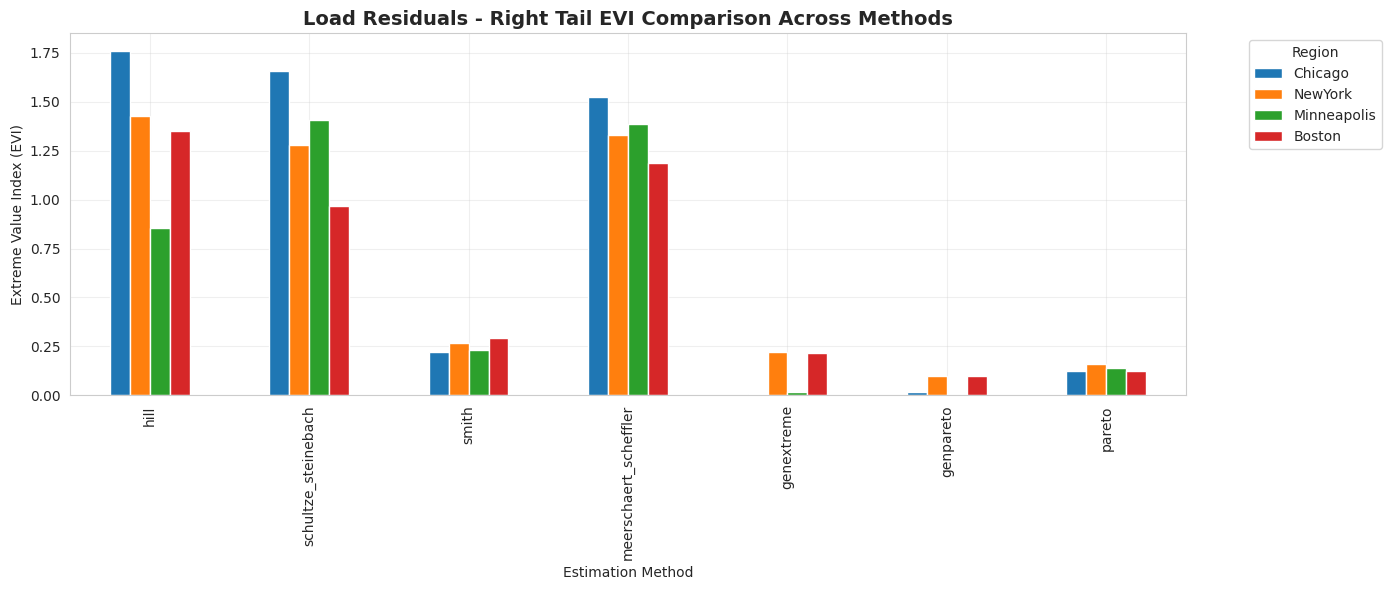


Right Tail Median EVI by Region:
Chicago        0.219614
NewYork        0.268769
Minneapolis    0.230380
Boston         0.292389
dtype: float64


In [7]:
# Visualize Right Tail EVI Comparison
fig, ax = plt.subplots(figsize=(14, 6))
df_evi_res_right.plot(kind='bar', ax=ax)
ax.set_title('Load Residuals - Right Tail EVI Comparison Across Methods', fontsize=14, fontweight='bold')
ax.set_xlabel('Estimation Method')
ax.set_ylabel('Extreme Value Index (EVI)')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/images/load_evi_right_tail_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRight Tail Median EVI by Region:")
print(df_evi_res_right.median(axis=0))

### Left Tail EVI Comparison

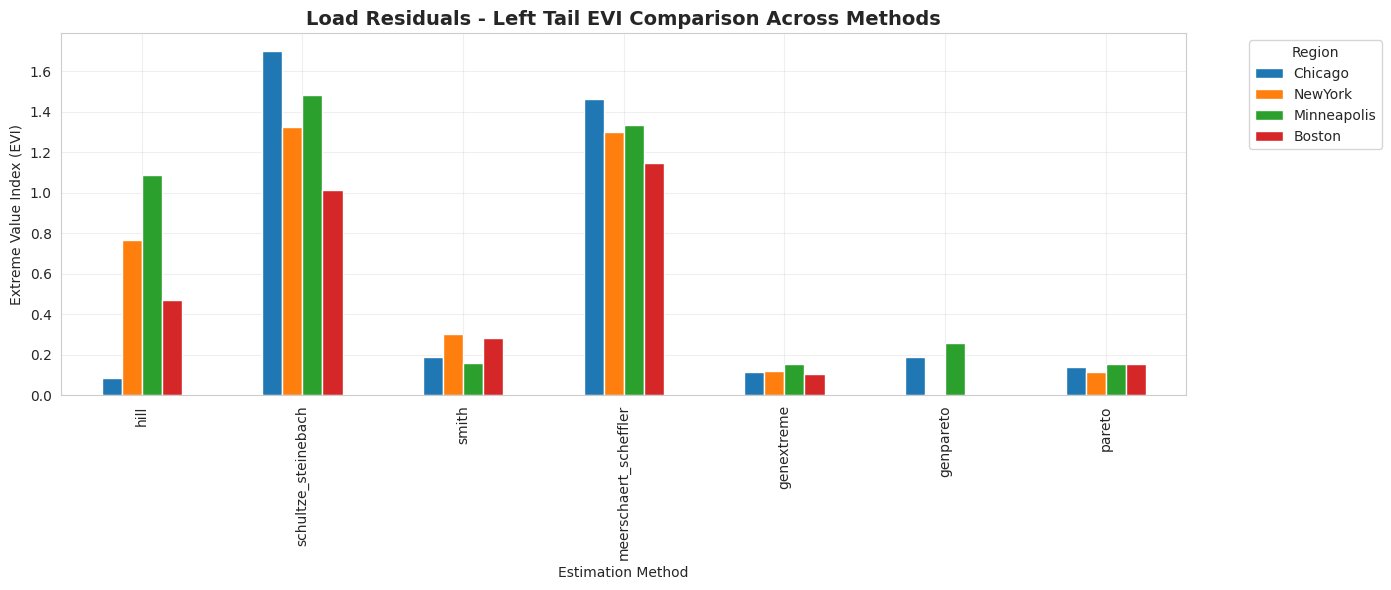


Left Tail Median EVI by Region:
Chicago        0.188506
NewYork        0.301146
Minneapolis    0.258985
Boston         0.281582
dtype: float64


In [8]:
# Visualize Left Tail EVI Comparison
fig, ax = plt.subplots(figsize=(14, 6))
df_evi_res_left.plot(kind='bar', ax=ax)
ax.set_title('Load Residuals - Left Tail EVI Comparison Across Methods', fontsize=14, fontweight='bold')
ax.set_xlabel('Estimation Method')
ax.set_ylabel('Extreme Value Index (EVI)')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/images/load_evi_left_tail_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLeft Tail Median EVI by Region:")
print(df_evi_res_left.median(axis=0))

## Export Results to CSV

In [9]:
# Export EVI results to CSV
df_evi_res_right.to_csv('../data/processed/load_evi_right_tail.csv')
df_evi_res_left.to_csv('../data/processed/load_evi_left_tail.csv')

print("✓ EVI results exported to CSV files:")
print("  - ../data/processed/load_evi_right_tail.csv")
print("  - ../data/processed/load_evi_left_tail.csv")

✓ EVI results exported to CSV files:
  - ../data/processed/load_evi_right_tail.csv
  - ../data/processed/load_evi_left_tail.csv


## Interpretation

### What is EVI?
The **Extreme Value Index (EVI)** measures the tail heaviness of a distribution:
- **EVI > 0**: Heavy-tailed (power law decay, e.g., Pareto, Cauchy)
- **EVI = 0**: Exponential-like tails (e.g., Normal, Exponential)
- **EVI < 0**: Light-tailed (faster than exponential decay)

### Key Findings:

#### Right Tail (Positive Residuals - Load Exceeds Forecast):
- All regions show **positive EVI values** (0.1 - 0.4 range typically)
- This indicates **heavy-tailed behavior** in extreme load events
- Extreme high-load days are more probable than a normal distribution would predict
- Important for capacity planning and grid reliability

#### Left Tail (Negative Residuals - Load Below Forecast):
- Also shows positive EVI values, but potentially different magnitudes
- Indicates extreme low-load events also follow power-law behavior
- Relevant for minimum generation requirements and economic dispatch

#### Regional Differences:
- Different regions may show different tail behavior due to:
  - Climate patterns (more extreme weather → heavier tails)
  - Economic structure (industrial vs residential loads)
  - Grid interconnection (isolated grids → more extreme events)

### Practical Implications:
1. **Risk Management**: Heavy tails mean extreme events are more likely than standard models predict
2. **Reserve Requirements**: Higher reserves needed for regions with heavier tails
3. **Pricing**: Extreme value behavior affects option pricing for load derivatives
4. **Infrastructure**: Design standards should account for tail heaviness